# Wikipedia Cloned-Language GPT: Results Dashboard

This notebook summarizes training, controlled SVA evaluation, and activation patching. It automatically uses the full patching run when available and otherwise falls back to the pilot run.

In [1]:
from pathlib import Path
import csv
import json

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 12})

def find_repo_root(start=Path.cwd()):
    for candidate in (start, *start.parents):
        if (candidate / 'configs').is_dir() and (candidate / 'src' / 'mllms').is_dir():
            return candidate
    raise FileNotFoundError('Run this notebook from inside the mllms-colab repository')

ROOT = find_repo_root()
RUN_DIR = ROOT / 'outputs/runs/gpt12_wikipedia_clone'
SVA_DIR = ROOT / 'outputs/evaluation/wikipedia_sva/best'
PATCH_ROOT = ROOT / 'outputs/interpretability/wikipedia_patching'
PATCH_DIR = PATCH_ROOT / 'best' if (PATCH_ROOT / 'best/metadata.json').is_file() else PATCH_ROOT / 'pilot'

required = [RUN_DIR / 'train_log.jsonl', SVA_DIR / 'sva_summary.json', PATCH_DIR / 'metadata.json']
missing = [path for path in required if not path.is_file()]
if missing:
    raise FileNotFoundError('Missing result files:\n' + '\n'.join(map(str, missing)))

display(Markdown(f'**Repository:** `{ROOT}`  \n**Patching run:** `{PATCH_DIR.name}`'))

**Repository:** `/home/students/ji/mllms/mllms-colab`  
**Patching run:** `best`

## Training

**Completed steps:** 77,560  
**Tokens seen:** 635,371,520  
**Best validation:** step 77,500, loss 3.6137  
**Original / clone validation PPL:** 37.23 / 36.98

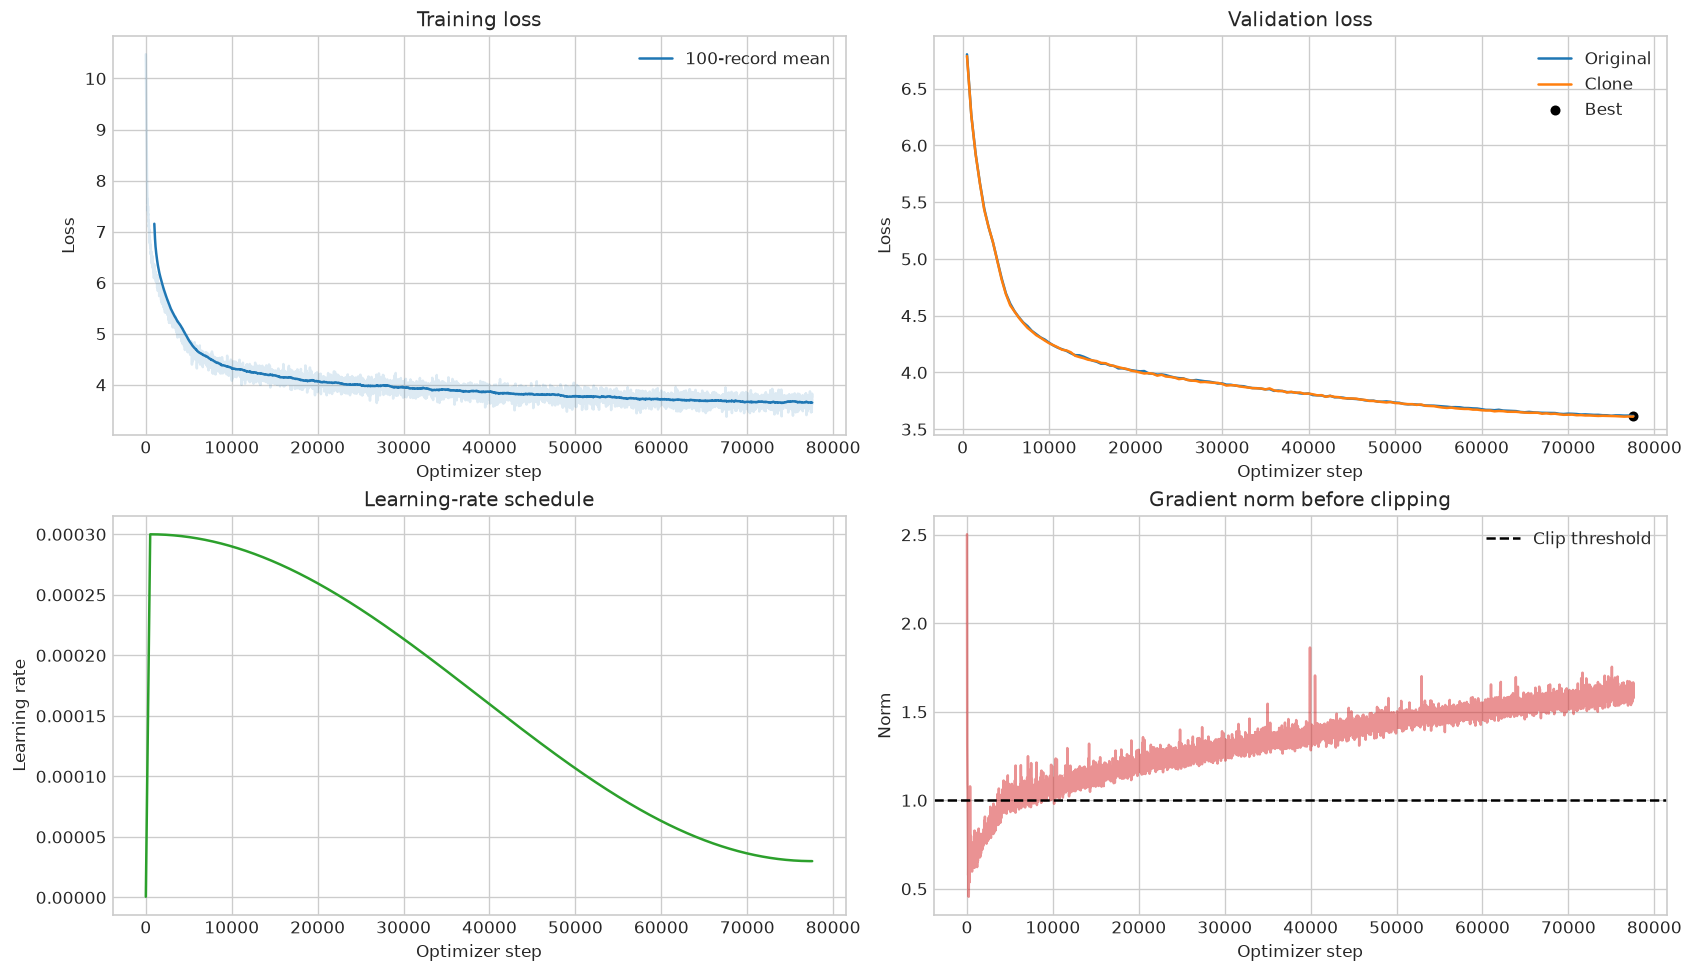

In [2]:
records = [json.loads(line) for line in (RUN_DIR / 'train_log.jsonl').read_text().splitlines()]
train = [row for row in records if row['type'] == 'train']
validation = [row for row in records if row['type'] == 'validation']
best_validation = min(validation, key=lambda row: row['average_loss'])
last_train = train[-1]

display(Markdown(
    f'**Completed steps:** {last_train["step"]:,}  \n'
    f'**Tokens seen:** {last_train["tokens_seen"]:,}  \n'
    f'**Best validation:** step {best_validation["step"]:,}, loss {best_validation["average_loss"]:.4f}  \n'
    f'**Original / clone validation PPL:** {best_validation["original_perplexity"]:.2f} / {best_validation["clone_perplexity"]:.2f}'
))

steps = np.array([row['step'] for row in train])
losses = np.array([row['train_loss'] for row in train])
window = 100
smooth = np.convolve(losses, np.ones(window) / window, mode='valid')
vsteps = np.array([row['step'] for row in validation])

fig, axes = plt.subplots(2, 2, figsize=(14, 8), constrained_layout=True)
axes[0, 0].plot(steps, losses, alpha=.15, color='tab:blue')
axes[0, 0].plot(steps[window-1:], smooth, color='tab:blue', label=f'{window}-record mean')
axes[0, 0].set(title='Training loss', xlabel='Optimizer step', ylabel='Loss')
axes[0, 0].legend()
axes[0, 1].plot(vsteps, [r['original_loss'] for r in validation], label='Original')
axes[0, 1].plot(vsteps, [r['clone_loss'] for r in validation], label='Clone')
axes[0, 1].scatter([best_validation['step']], [best_validation['average_loss']], color='black', s=25, label='Best')
axes[0, 1].set(title='Validation loss', xlabel='Optimizer step', ylabel='Loss')
axes[0, 1].legend()
axes[1, 0].plot(steps, [r['learning_rate'] for r in train], color='tab:green')
axes[1, 0].set(title='Learning-rate schedule', xlabel='Optimizer step', ylabel='Learning rate')
axes[1, 1].plot(steps, [r['gradient_norm'] for r in train], alpha=.5, color='tab:red')
axes[1, 1].axhline(1.0, color='black', linestyle='--', label='Clip threshold')
axes[1, 1].set(title='Gradient norm before clipping', xlabel='Optimizer step', ylabel='Norm')
axes[1, 1].legend()
plt.show()

## Controlled subject–verb agreement

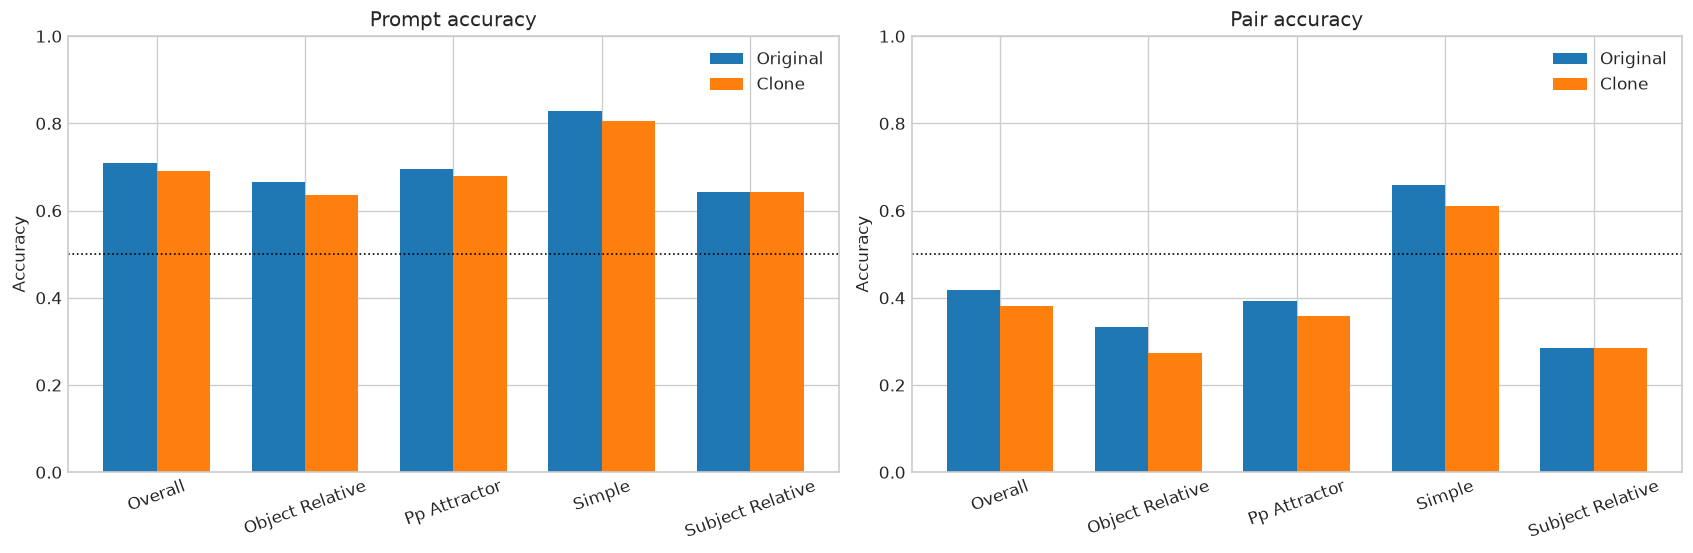

**Original accuracy:** 70.81%  
**Clone accuracy:** 69.06%  
**Joint sanity pairs:** 812

In [3]:
sva = json.loads((SVA_DIR / 'sva_summary.json').read_text())
groups = [('overall', sva['overall']), *sva['by_task'].items()]
labels = [name.replace('_', ' ').title() for name, _ in groups]
x = np.arange(len(groups))
width = .36

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), constrained_layout=True)
for offset, language, color in [(-width/2, 'original', 'tab:blue'), (width/2, 'clone', 'tab:orange')]:
    accuracy = [group[language]['accuracy'] for _, group in groups]
    pair_accuracy = [group[language]['pair_accuracy'] for _, group in groups]
    axes[0].bar(x + offset, accuracy, width, label=language.title(), color=color)
    axes[1].bar(x + offset, pair_accuracy, width, label=language.title(), color=color)
for axis, title in zip(axes, ['Prompt accuracy', 'Pair accuracy']):
    axis.axhline(.5, color='black', linestyle=':', linewidth=1)
    axis.set(title=title, ylabel='Accuracy', ylim=(0, 1), xticks=x, xticklabels=labels)
    axis.tick_params(axis='x', rotation=20)
    axis.legend()
plt.show()

overall = sva['overall']
display(Markdown(
    f'**Original accuracy:** {overall["original"]["accuracy"]:.2%}  \n'
    f'**Clone accuracy:** {overall["clone"]["accuracy"]:.2%}  \n'
    f'**Joint sanity pairs:** {overall["joint_sanity_pairs"]:,}'
))

### SVA acquisition over training

The checkpoint sweep shows when agreement behavior emerges. LD is the sequence log-probability difference between the grammatically matching and mismatching answer.

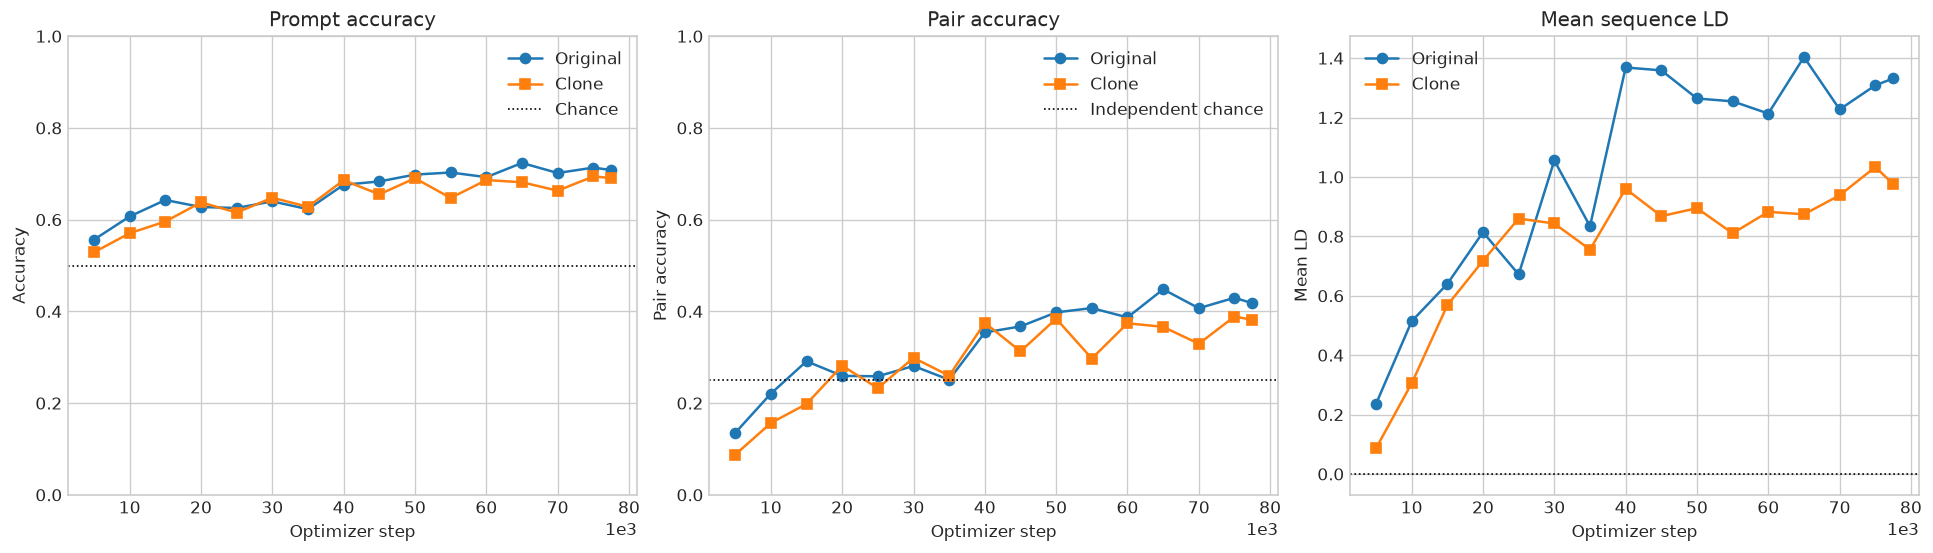

**Trajectory checkpoints:** 16  
**Range:** step 5,000–77,500

In [4]:
sweep_root = SVA_DIR.parent / 'checkpoints'
sweep_paths = sorted(sweep_root.glob('step_*/sva_summary.json'))
checkpoint_summaries = {}
for path in sweep_paths:
    summary = json.loads(path.read_text())
    checkpoint_summaries[int(summary['checkpoint_step'])] = summary
# Include the selected best checkpoint (77,500) after the numbered sweep.
checkpoint_summaries[int(sva['checkpoint_step'])] = sva
trajectory = [checkpoint_summaries[step] for step in sorted(checkpoint_summaries)]

if not sweep_paths:
    display(Markdown('Checkpoint sweep results were not found; showing only the selected checkpoint.'))

trajectory_steps = np.array([row['checkpoint_step'] for row in trajectory])
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), constrained_layout=True)
language_styles = [('original', 'tab:blue', 'o'), ('clone', 'tab:orange', 's')]
for language, color, marker in language_styles:
    axes[0].plot(
        trajectory_steps, [row['overall'][language]['accuracy'] for row in trajectory],
        color=color, marker=marker, label=language.title(),
    )
    axes[1].plot(
        trajectory_steps, [row['overall'][language]['pair_accuracy'] for row in trajectory],
        color=color, marker=marker, label=language.title(),
    )
    axes[2].plot(
        trajectory_steps, [row['overall'][language]['mean_logit_difference'] for row in trajectory],
        color=color, marker=marker, label=language.title(),
    )
axes[0].axhline(.5, color='black', linestyle=':', linewidth=1, label='Chance')
axes[1].axhline(.25, color='black', linestyle=':', linewidth=1, label='Independent chance')
axes[2].axhline(0, color='black', linestyle=':', linewidth=1)
for axis, title, ylabel in zip(
    axes,
    ['Prompt accuracy', 'Pair accuracy', 'Mean sequence LD'],
    ['Accuracy', 'Pair accuracy', 'Mean LD'],
):
    axis.set(title=title, xlabel='Optimizer step', ylabel=ylabel)
    axis.ticklabel_format(axis='x', style='sci', scilimits=(3, 3))
    axis.legend()
axes[0].set_ylim(0, 1)
axes[1].set_ylim(0, 1)
plt.show()

display(Markdown(
    f'**Trajectory checkpoints:** {len(trajectory)}  \n'
    f'**Range:** step {trajectory_steps.min():,}–{trajectory_steps.max():,}'
))

## Activation patching

Recovery is `(LD_patched - LD_corrupted) / (LD_clean - LD_corrupted)`. A value near 1 indicates strong recovery of clean behavior; a value near 0 indicates little causal effect.

**Input sanity pairs:** 812  
**Aligned and sanity-passed:** 618  
**Patched examples:** 618  
**Task counts:** `{'pp_attractor': 134, 'simple': 327, 'object_relative': 72, 'subject_relative': 85}`

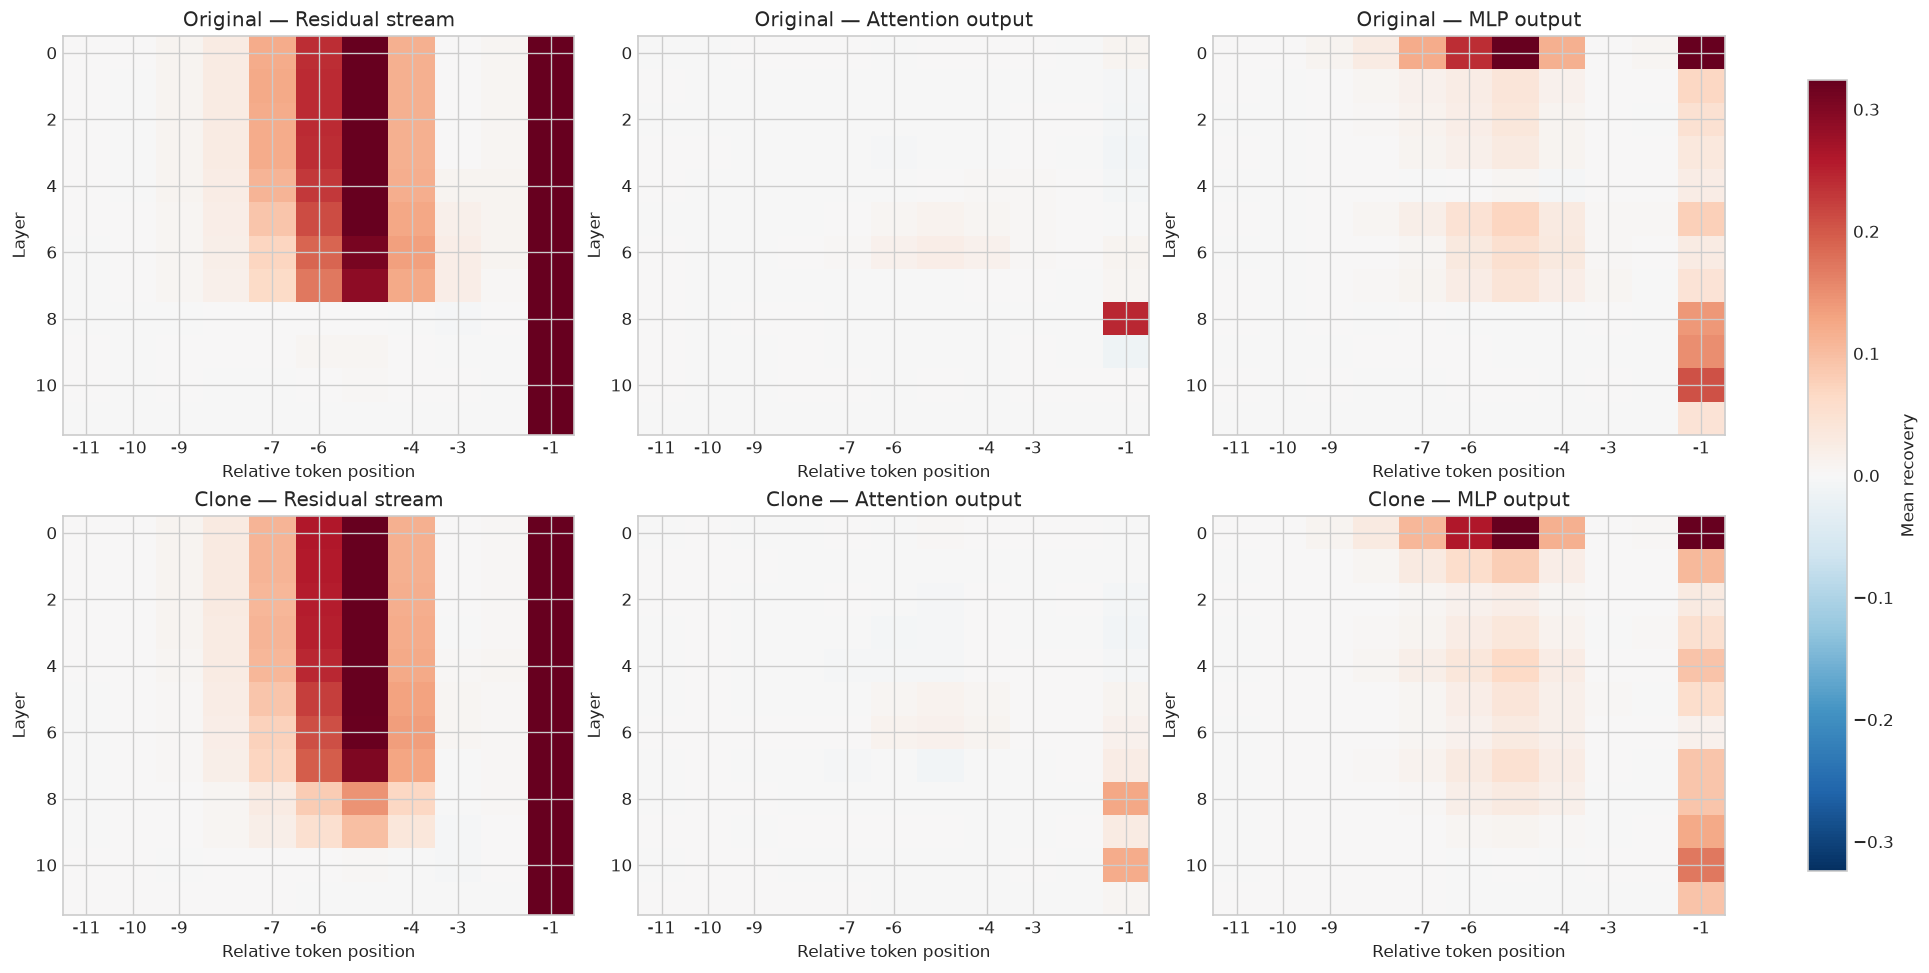

In [5]:
patch_meta = json.loads((PATCH_DIR / 'metadata.json').read_text())
display(Markdown(
    f'**Input sanity pairs:** {patch_meta["num_input_pairs"]:,}  \n'
    f'**Aligned and sanity-passed:** {patch_meta["num_joint_sanity_pairs_available"]:,}  \n'
    f'**Patched examples:** {patch_meta["num_patched_pairs"]:,}  \n'
    f'**Task counts:** `{patch_meta["patched_task_counts"]}`'
))

components = [('resid_post', 'Residual stream'), ('attn_out', 'Attention output'), ('mlp_out', 'MLP output')]
patch_values = {
    (language, component): np.load(PATCH_DIR / language / f'{component}_recovery_mean.npy')
    for language in ('original', 'clone')
    for component, _ in components
}
finite_values = np.concatenate([
    np.abs(values[np.isfinite(values)]) for values in patch_values.values()
])
patch_limit = max(float(np.percentile(finite_values, 95)), 1e-4)
fig, axes = plt.subplots(2, 3, figsize=(16, 8), constrained_layout=True)
for row_index, language in enumerate(('original', 'clone')):
    archive = np.load(PATCH_DIR / language / 'per_example_scores.npz')
    relative_positions = archive['relative_positions']
    for axis, (component, title) in zip(axes[row_index], components):
        values = patch_values[(language, component)]
        image = axis.imshow(values, aspect='auto', cmap='RdBu_r', vmin=-patch_limit, vmax=patch_limit)
        ticks = np.unique(np.linspace(0, len(relative_positions)-1, min(8, len(relative_positions))).astype(int))
        axis.set(title=f'{language.title()} — {title}', xlabel='Relative token position', ylabel='Layer')
        axis.set_xticks(ticks, relative_positions[ticks])
fig.colorbar(image, ax=axes.ravel().tolist(), label='Mean recovery', shrink=.9)
plt.show()

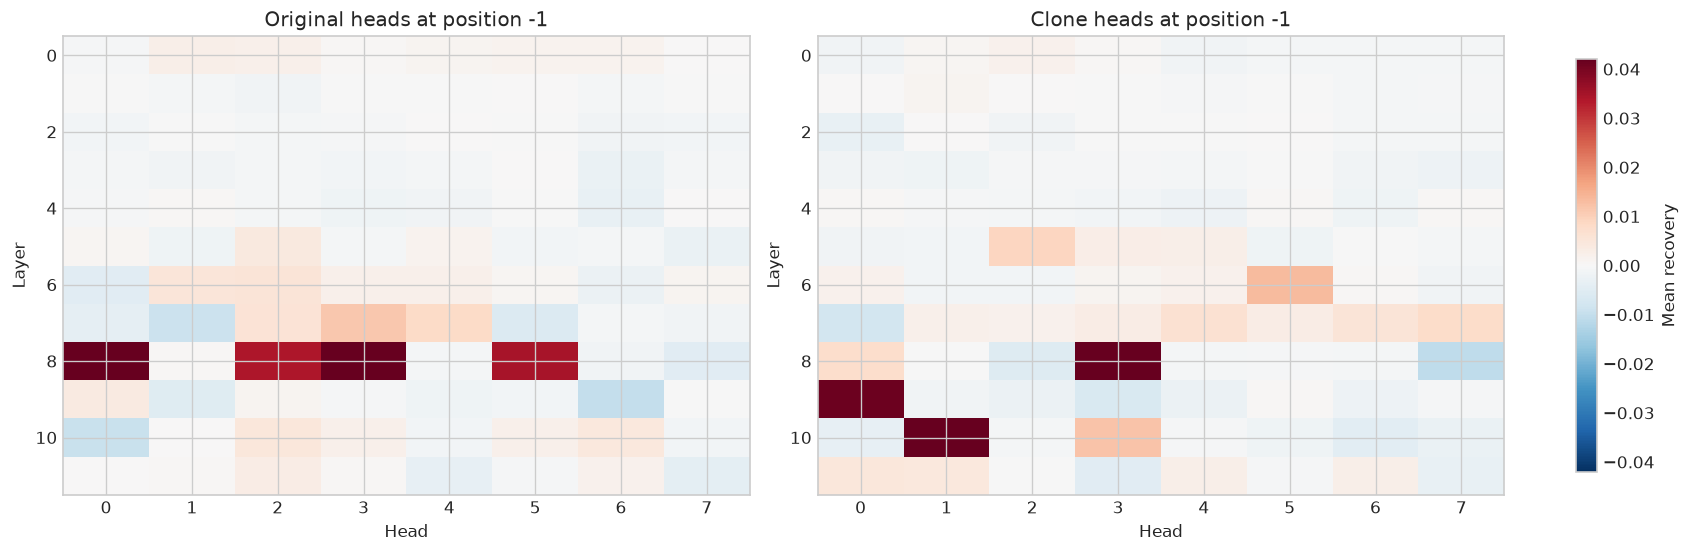

In [6]:
# Attention-head recovery at the prediction position (-1), with one shared scale.
head_values = {}
for language in ('original', 'clone'):
    archive = np.load(PATCH_DIR / language / 'per_example_scores.npz')
    positions = archive['relative_positions']
    position_index = int(np.where(positions == -1)[0][0])
    head_values[language] = np.load(
        PATCH_DIR / language / 'head_out_recovery_mean.npy'
    )[:, position_index, :]
finite_heads = np.concatenate([
    np.abs(values[np.isfinite(values)]) for values in head_values.values()
])
head_limit = max(float(np.percentile(finite_heads, 98)), 1e-4)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), constrained_layout=True)
for axis, language in zip(axes, ('original', 'clone')):
    values = head_values[language]
    image = axis.imshow(values, aspect='auto', cmap='RdBu_r', vmin=-head_limit, vmax=head_limit)
    axis.set(title=f'{language.title()} heads at position -1', xlabel='Head', ylabel='Layer')
    axis.set_xticks(np.arange(values.shape[1]))
fig.colorbar(image, ax=axes.ravel().tolist(), label='Mean recovery', shrink=.9)
plt.show()

In [7]:
# Rank the most positive attention heads at the prediction position.
table = ['| Language | Layer | Head | Mean recovery | N |', '|---|---:|---:|---:|---:|']
for language in ('original', 'clone'):
    rows = list(csv.DictReader((PATCH_DIR / language / 'mean_scores.csv').open()))
    heads = [row for row in rows if row['component'] == 'head_out' and row['relative_position'] == '-1']
    heads.sort(key=lambda row: float(row['mean_recovery']), reverse=True)
    for row in heads[:10]:
        table.append(
            f'| {language.title()} | {row["layer"]} | {row["head"]} | '
            f'{float(row["mean_recovery"]):.4f} | {row["num_examples"]} |'
        )
display(Markdown('\n'.join(table)))

| Language | Layer | Head | Mean recovery | N |
|---|---:|---:|---:|---:|
| Original | 8 | 3 | 0.1324 | 618 |
| Original | 8 | 0 | 0.0465 | 618 |
| Original | 8 | 5 | 0.0347 | 618 |
| Original | 8 | 2 | 0.0341 | 618 |
| Original | 7 | 3 | 0.0113 | 618 |
| Original | 7 | 4 | 0.0080 | 618 |
| Original | 7 | 2 | 0.0058 | 618 |
| Original | 6 | 2 | 0.0055 | 618 |
| Original | 6 | 1 | 0.0050 | 618 |
| Original | 10 | 2 | 0.0049 | 618 |
| Clone | 8 | 3 | 0.1348 | 618 |
| Clone | 10 | 1 | 0.1215 | 618 |
| Clone | 9 | 0 | 0.0411 | 618 |
| Clone | 6 | 5 | 0.0132 | 618 |
| Clone | 10 | 3 | 0.0120 | 618 |
| Clone | 5 | 2 | 0.0089 | 618 |
| Clone | 7 | 7 | 0.0077 | 618 |
| Clone | 8 | 0 | 0.0073 | 618 |
| Clone | 7 | 4 | 0.0065 | 618 |
| Clone | 7 | 6 | 0.0055 | 618 |

### Recovery by syntactic construction

The following panels recompute prediction-position attention-head recovery separately for each SVA construction. All eight panels use one shared symmetric color scale.

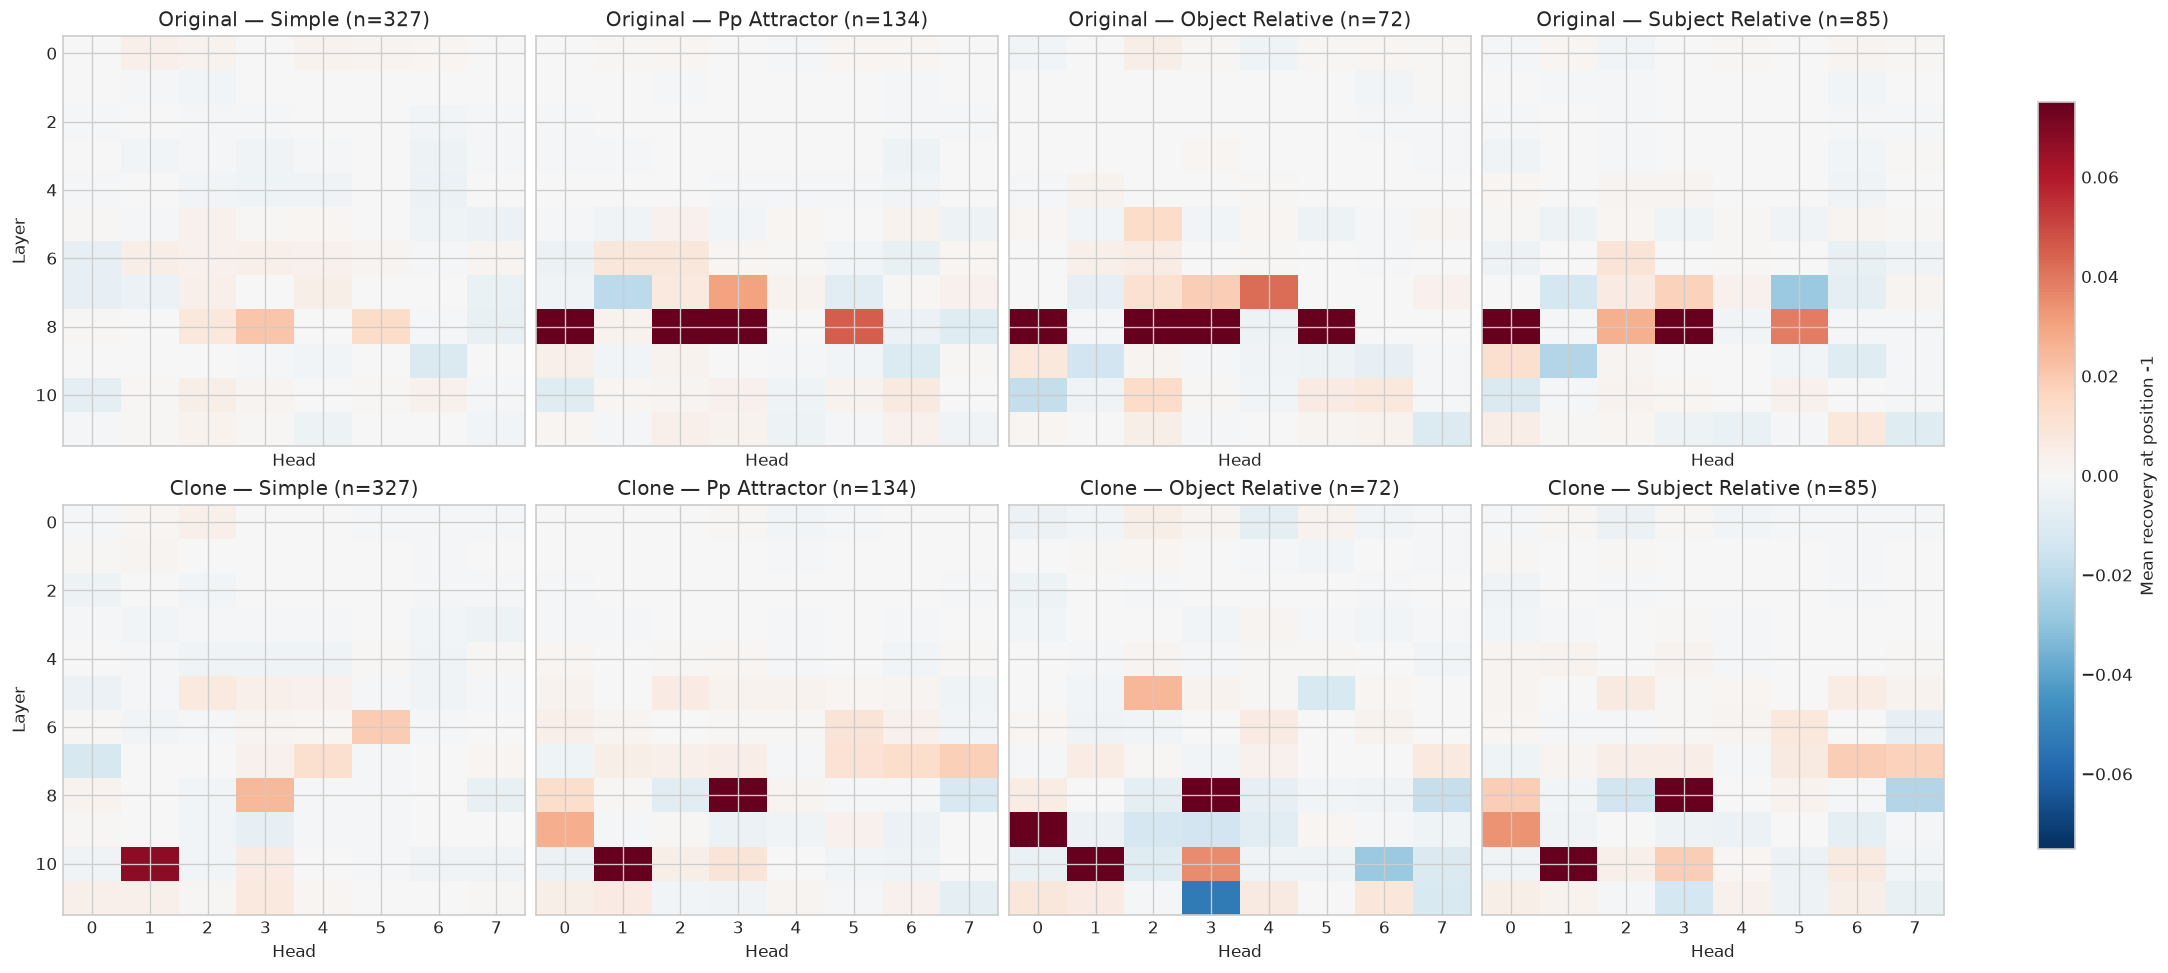

In [8]:
sanity_records = {
    row['sample_id']: row
    for row in (
        json.loads(line)
        for line in (SVA_DIR / 'sanity_pairs.jsonl').read_text().splitlines()
    )
}
tasks = ['simple', 'pp_attractor', 'object_relative', 'subject_relative']
task_titles = [task.replace('_', ' ').title() for task in tasks]
task_head_values = {}
task_counts = {}
for language in ('original', 'clone'):
    archive = np.load(PATCH_DIR / language / 'per_example_scores.npz')
    sample_ids = archive['sample_ids'].astype(str)
    positions = archive['relative_positions']
    prediction_index = int(np.where(positions == -1)[0][0])
    per_example_heads = archive['head_out_recovery'][:, :, prediction_index, :]
    for task in tasks:
        mask = np.array([sanity_records[sample_id]['task'] == task for sample_id in sample_ids])
        task_counts[task] = int(mask.sum())
        task_head_values[(language, task)] = np.nanmean(per_example_heads[mask], axis=0)

finite_task_heads = np.concatenate([
    np.abs(values[np.isfinite(values)]) for values in task_head_values.values()
])
task_head_limit = max(float(np.percentile(finite_task_heads, 98)), 1e-4)
fig, axes = plt.subplots(2, 4, figsize=(18, 8), constrained_layout=True, sharex=True, sharey=True)
for row_index, language in enumerate(('original', 'clone')):
    for column_index, (task, title) in enumerate(zip(tasks, task_titles)):
        axis = axes[row_index, column_index]
        image = axis.imshow(
            task_head_values[(language, task)], aspect='auto', cmap='RdBu_r',
            vmin=-task_head_limit, vmax=task_head_limit,
        )
        axis.set_title(f'{language.title()} — {title} (n={task_counts[task]})')
        axis.set_xlabel('Head')
        axis.set_xticks(np.arange(8))
        if column_index == 0:
            axis.set_ylabel('Layer')
fig.colorbar(image, ax=axes.ravel().tolist(), label='Mean recovery at position -1', shrink=.85)
plt.show()

### Original–clone similarity

In [9]:
similarity_rows = []
for component, title in [*components, ('head_out', 'Attention heads')]:
    original = np.load(PATCH_DIR / 'original' / f'{component}_recovery_mean.npy')
    clone = np.load(PATCH_DIR / 'clone' / f'{component}_recovery_mean.npy')
    valid = np.isfinite(original) & np.isfinite(clone)
    similarity_rows.append((
        title,
        float(np.corrcoef(original[valid], clone[valid])[0, 1]),
        float(np.mean(np.abs(original[valid] - clone[valid]))),
    ))
table = ['| Component | Pearson r | Mean absolute difference |', '|---|---:|---:|']
for title, correlation, difference in similarity_rows:
    table.append(f'| {title} | {correlation:.4f} | {difference:.4f} |')
display(Markdown('\n'.join(table)))

| Component | Pearson r | Mean absolute difference |
|---|---:|---:|
| Residual stream | 0.9919 | 0.0089 |
| Attention output | 0.6992 | 0.0032 |
| MLP output | 0.9714 | 0.0077 |
| Attention heads | 0.6456 | 0.0007 |

### Interpretation notes

- Treat pilot rankings as diagnostic rather than final evidence because the pilot task distribution is small and uneven.
- Compare original and clone patterns, not only their absolute maxima.
- Prefer sites that remain strong in the full run and across multiple SVA constructions.
- The current patching analysis includes only examples whose clean and corrupted prompts have equal tokenized lengths.